In [9]:
%matplotlib inline
#Reference from https://pytorch.org/

In [10]:
from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.nn import Tanh, Linear, ReLU, Sequential, Conv2d, MaxPool2d, Sigmoid, BatchNorm2d, Flatten, ConvTranspose2d

plt.ion()   # interactive mode

In [11]:
# Data augmentation and normalization for training
# Just normalization for validation
'''
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
'''
data_transforms = {
    'train': transforms.Compose([
        #transforms.RandomResizedCrop(224),
        transforms.Resize([224, 224]),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize([224, 224]),
        #transforms.Resize(256),
        #transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


data_transforms = {
    'train': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


data_dir = '../AddMoreData061823/Class3/TTV'
l = []
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
#l.append(datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test']))
image_datasetss = torch.utils.data.ConcatDataset(l)
image_datasets = {}
image_datasets['train'] = image_datasetss
image_datasets['test'] = datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test'])
image_datasets['val'] = datasets.ImageFolder(os.path.join(data_dir, 'val'), data_transforms['test'])
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=5,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'test', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test', 'val']}
class_names = image_datasets['test'].classes
print(class_names)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(len( image_datasets['train']))
print(len( image_datasets['val']))
print(len( image_datasets['test']))

['0', '1', '2']
3016
93
98


Visualize a few images
^^^^^^^^^^^^^^^^^^^^^^
Let's visualize a few training images so as to understand the data
augmentations.



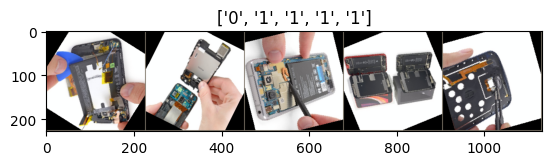

In [12]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [13]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs+1):
        print('Epoch {}/{}'.format(epoch+1, num_epochs))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    #print(outputs.shape)
                    #print(outputs)
                    #print(labels)
                    loss = criterion(outputs, labels)
    
                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

Visualizing the model predictions
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Generic function to display predictions for a few images




In [14]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            m = nn.Softmax(dim=1)
            proOutput = m(outputs)
            pros = proOutput.detach().cpu().numpy()
            #print(pros)
            #_, preds = torch.max(outputs, 1)
            #pro = torch.max(proOutput, dim=1)[0]
            #_, predsmin = torch.min(outputs, 1)
            #promin = torch.min(proOutput, dim=1)[0]

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                #ax.set_title('predicted: %s with %s probabilities' %(class_names[preds[j]], round(pro[j].item(),4)))
                print('Actual label: %s' %(class_names[labels[j].item()]))
                for jj in range(3):
                    print('predicted: %s with %s probabilities' %(class_names[jj], round(pros[j][jj],4)))
                #print('predicted: %s with %s probabilities' %(class_names[1], round(pros[j][1],4)))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
                
        model.train(mode=was_training)

#visualize_model(model_ft)

In [15]:
model_ft = models.resnet50(pretrained=True) #load googlenet.

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

print(model_ft)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
class Res50_rm3rdlayer(nn.Module):
    def __init__(self):
        super(Res50_rm3rdlayer, self).__init__()
        self.conv1 = model_ft.conv1
        self.bn1 = model_ft.bn1
        self.relu = model_ft.relu
        self.maxpool = model_ft.maxpool
        self.layer1 = model_ft.layer1
        self.layer2 = model_ft.layer2
        self.resize = Conv2d(512, 1024, kernel_size=(1, 1), stride=(1, 1), bias=False)
        self.layer4 = model_ft.layer4
        self.avgpool = model_ft.avgpool
        self.fc = nn.Linear(2048 ,3)
        
        
    def forward(self, x):
        # Pass data through conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.resize(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)

        return x
    
Res = Res50_rm3rdlayer()
Res = Res.to(device)
print(Res)

Res50_rm3rdlayer(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), s

Train and evaluate
^^^^^^^^^^^^^^^^^^

It should take around 15-25 min on CPU. On GPU though, it takes less than a
minute.




In [17]:
ep = 100
model_ft = train_model(Res, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=ep)

Epoch 1/100
----------
train Loss: 0.7841 Acc: 0.7125
val Loss: 0.6425 Acc: 0.7419

Epoch 2/100
----------
train Loss: 0.5855 Acc: 0.7626
val Loss: 0.5313 Acc: 0.8065

Epoch 3/100
----------
train Loss: 0.4891 Acc: 0.8087
val Loss: 0.5267 Acc: 0.7957

Epoch 4/100
----------
train Loss: 0.4370 Acc: 0.8276
val Loss: 0.4252 Acc: 0.8172

Epoch 5/100
----------
train Loss: 0.3570 Acc: 0.8631
val Loss: 0.3956 Acc: 0.8817

Epoch 6/100
----------
train Loss: 0.3174 Acc: 0.8806
val Loss: 0.4900 Acc: 0.8065

Epoch 7/100
----------
train Loss: 0.2607 Acc: 0.9032
val Loss: 0.4717 Acc: 0.8172

Epoch 8/100
----------
train Loss: 0.2088 Acc: 0.9320
val Loss: 0.3877 Acc: 0.8817

Epoch 9/100
----------
train Loss: 0.1779 Acc: 0.9436
val Loss: 0.4559 Acc: 0.8710

Epoch 10/100
----------
train Loss: 0.1723 Acc: 0.9489
val Loss: 0.4140 Acc: 0.8817

Epoch 11/100
----------
train Loss: 0.1562 Acc: 0.9566
val Loss: 0.3909 Acc: 0.8925

Epoch 12/100
----------
train Loss: 0.1434 Acc: 0.9635
val Loss: 0.3973 Ac

val Loss: 0.4102 Acc: 0.8925

Epoch 98/100
----------
train Loss: 0.1255 Acc: 0.9655
val Loss: 0.3806 Acc: 0.8925

Epoch 99/100
----------
train Loss: 0.1196 Acc: 0.9731
val Loss: 0.4065 Acc: 0.8817

Epoch 100/100
----------
train Loss: 0.1221 Acc: 0.9682
val Loss: 0.3890 Acc: 0.8925

Epoch 101/100
----------
train Loss: 0.1355 Acc: 0.9622
val Loss: 0.3538 Acc: 0.9032

Training complete in 65m 22s
Best val Acc: 0.924731


Actual label: 2
predicted: 0 with 0.0491 probabilities
predicted: 1 with 0.6206 probabilities
predicted: 2 with 0.3302 probabilities


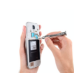

Actual label: 0
predicted: 0 with 0.9976 probabilities
predicted: 1 with 0.001 probabilities
predicted: 2 with 0.0014 probabilities


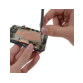

Actual label: 1
predicted: 0 with 0.0008 probabilities
predicted: 1 with 0.4405 probabilities
predicted: 2 with 0.5588 probabilities


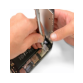

Actual label: 1
predicted: 0 with 0.0055 probabilities
predicted: 1 with 0.9904 probabilities
predicted: 2 with 0.0041 probabilities


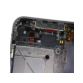

Actual label: 1
predicted: 0 with 0.0006 probabilities
predicted: 1 with 0.9697 probabilities
predicted: 2 with 0.0297 probabilities


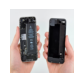

Actual label: 0
predicted: 0 with 0.2519 probabilities
predicted: 1 with 0.7141 probabilities
predicted: 2 with 0.034 probabilities


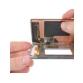

Actual label: 1
predicted: 0 with 0.0558 probabilities
predicted: 1 with 0.9385 probabilities
predicted: 2 with 0.0057 probabilities


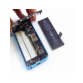

Actual label: 2
predicted: 0 with 0.0058 probabilities
predicted: 1 with 0.0972 probabilities
predicted: 2 with 0.897 probabilities


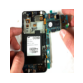

Actual label: 0
predicted: 0 with 0.1586 probabilities
predicted: 1 with 0.8212 probabilities
predicted: 2 with 0.0202 probabilities


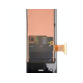

Actual label: 1
predicted: 0 with 0.1107 probabilities
predicted: 1 with 0.8603 probabilities
predicted: 2 with 0.0289 probabilities


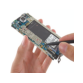

In [18]:
visualize_model(model_ft, 10)

In [19]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['train']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s train images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 3016 train images: 99 %
tensor([[4.0000e+02, 0.0000e+00, 0.0000e+00],
        [7.0000e+00, 2.1750e+03, 2.0000e+00],
        [0.0000e+00, 0.0000e+00, 4.3200e+02]])
tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00],
        [3.2051e-03, 9.9588e-01, 9.1575e-04],
        [0.0000e+00, 0.0000e+00, 1.0000e+00]])


In [20]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['val']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s val images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 93 val images: 92 %
tensor([[11.,  1.,  0.],
        [ 3., 65.,  0.],
        [ 0.,  3., 10.]])
tensor([[0.9167, 0.0833, 0.0000],
        [0.0441, 0.9559, 0.0000],
        [0.0000, 0.2308, 0.7692]])


In [21]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['test']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s test images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 98 test images: 85 %
tensor([[10.,  4.,  0.],
        [ 2., 64.,  3.],
        [ 0.,  5., 10.]])
tensor([[0.7143, 0.2857, 0.0000],
        [0.0290, 0.9275, 0.0435],
        [0.0000, 0.3333, 0.6667]])


In [22]:
if not os.path.exists('trained models'):
   os.makedirs('trained models')
PATH = './trained models/Res50_rm3rd-TTVClass3-BestEP%s.pth' %(ep)
torch.save(model_ft.state_dict(), PATH)